In [1]:
from brian2 import *
from sheet_eqs import *
from sheet_con import build_pen_to_epg_array
import numpy as np
import time
import brian2 as b2

def map_index(i):
    g = i // 3  # subgroup index
    o = i % 3   # offset in subgroup
    return g * 48 + o

w_EE = 0.719, # EB <-> EB
w_EI = 0.143, # R -> EB
w_IE = 0.740, # EB -> R
w_II = 0.01, # R <-> R
w_PP = 0.01, # PEN <-> PEN
w_EP = 0.012, # EB -> PEN 
w_PE = 0.709, # PEN -> EB
sigma = 0.0001, # noise level


E_l    = -0.07  # leak reversal potential (volt)

# create neuron
EPG = NeuronGroup(256*3, model=eqs_EPG, threshold='v>Vth', reset='v=Vr', refractory='1*ms', method='euler')
PENx = NeuronGroup(256*3,model=eqs_PENx, threshold='v>Vth', reset='v=Vr', refractory='1*ms', method='euler')
PENy = NeuronGroup(256*3,model=eqs_PENy, threshold='v>Vth', reset='v=Vr', refractory='1*ms', method='euler')
R = NeuronGroup(3,model=eqs_R, threshold='v>Vth', reset='v=Vr', refractory='1*ms', method='euler')

# initialize neuron
EPG.v = E_l
PENx.v = E_l
PENy.v = E_l
R.v = E_l

# EPG_groups = [EPG[i:i+3] for i in range(0, 256*3, 3)]
EPG_groups = [[EPG[i*48 + j*3:i*48 + j*3 + 3] for j in range(16)] for i in range(16)]
PENx_groups = [[PENx[i*48 + j*3:i*48 + j*3 + 3] for j in range(16)] for i in range(16)]
PENy_groups = [[PENy[i*48 + j*3:i*48 + j*3 + 3] for j in range(16)] for i in range(16)]

# ========= EPG -> EPG =========
# print(f'{time.strftime("%H:%M:%S")} [info] Building EPG -> EPG connections')

S_EE = Synapses(EPG, EPG, Ach_eqs_EE, on_pre='s_ach += w_EE', method='euler')
S_EE.connect(condition='i//3 == j//3 and i != j')

# ========= PEN -> PEN =========
# print(f'{time.strftime("%H:%M:%S")} [info] Building PEN -> PEN connections')
S_PPx = Synapses(PENx, PENx, Ach_eqs_PPx, on_pre='s_ach += w_PP', method='euler')
S_PPx.connect(condition='i//3 == j//3 and i != j')
S_PPy = Synapses(PENy, PENy, Ach_eqs_PPy, on_pre='s_ach += w_PP', method='euler')
S_PPy.connect(condition='i//3 == j//3 and i != j')

# ========= EPG -> R =========
# print(f'{time.strftime("%H:%M:%S")} [info] Building EPG -> R connections')
S_EI = Synapses(EPG, R, model=Ach_eqs_EI, on_pre='s_ach += w_EI', method='euler')
S_EI.connect(condition='True')

# ========= R   -> EPG =========
# print(f'{time.strftime("%H:%M:%S")} [info] Building R -> EPG connections')
S_IE = Synapses(R, EPG, model=GABA_eqs, on_pre='s_GABAA += w_IE', method='euler')
S_IE.connect(condition='True')

# ========= R <-> R =========
# print(f'{time.strftime("%H:%M:%S")} [info] Building R <-> R connections')
S_II = Synapses(R, R, model=GABA_eqs_i, on_pre='s_GABAA += w_II', method='euler')
S_II.connect(condition='i != j')

# ========= EPG -> PEN =========
# print(f'{time.strftime("%H:%M:%S")} [info] Building EPG -> PEN connections')
S_EPx = Synapses(EPG, PENx, Ach_eqs_EPx, on_pre='s_ach += w_EP', method='euler')
S_EPx.connect(condition='i//3 == j//3')
S_EPy = Synapses(EPG, PENy, Ach_eqs_EPy, on_pre='s_ach += w_EP', method='euler')
S_EPy.connect(condition='i//3 == j//3')

# ========= PEN -> EPG (optimized by connectivity matrix) =========
# print(f'{time.strftime("%H:%M:%S")} [info] Building PEN -> EPG connections')
S_PxE_2 = Synapses(PENx, EPG, model=Ach_eqs_PxE_2, on_pre='s_ach += 2*w_PE', method='euler')
S_PxE_1 = Synapses(PENx, EPG, model=Ach_eqs_PxE_1, on_pre='s_ach += 1*w_PE', method='euler')
S_PyE_2 = Synapses(PENy, EPG, model=Ach_eqs_PyE_2, on_pre='s_ach += 2*w_PE', method='euler')
S_PyE_1 = Synapses(PENy, EPG, model=Ach_eqs_PyE_1, on_pre='s_ach += 1*w_PE', method='euler')

pre2, post2, pre1, post1 = build_pen_to_epg_array()

# # ---- build all connections at once ----
for k in range(16):
    S_PxE_2.connect(i=pre2+k*48, j=post2+k*48)
    S_PxE_1.connect(i=pre1+k*48, j=post1+k*48)
    S_PyE_2.connect(i=map_index(pre2)+k*3, j=map_index(post2)+k*3)
    S_PyE_1.connect(i=map_index(pre1)+k*3, j=map_index(post1)+k*3)

    # S_PxE_2.connect(i=pre2+k*48, j=(post2+8*16*3+k*48)%768)
    # S_PxE_1.connect(i=pre1+k*48, j=(post1+8*16*3+k*48)%768)
    # S_PyE_2.connect(i=map_index(pre2)+k*3, j=(map_index(post2)+24+k*3)%768)
    # S_PyE_1.connect(i=map_index(pre1)+k*3, j=(map_index(post1)+24+k*3)%768)



INFO       Cache size for target 'cython': 1352 MB.
You can call clear_cache('cython') to delete all files from the cache or manually delete files in the '/home/pajucg/.cython/brian_extensions' directory. [brian2]


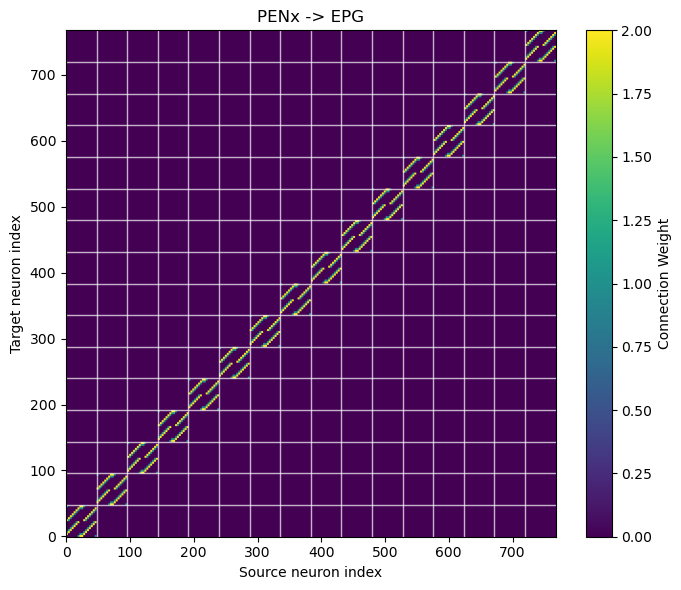

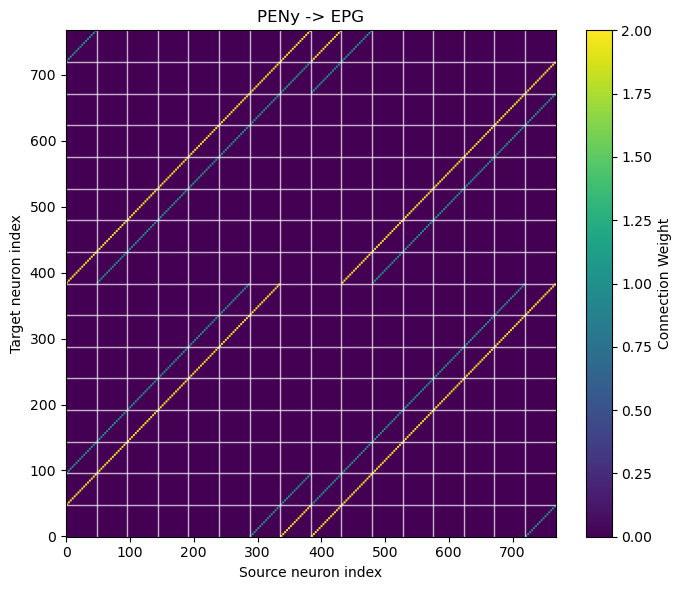

In [3]:
def visualise_connectivity(S_list, weights, title=""):
    # Combine all synapses into one visualization
    if not isinstance(S_list, list):
        S_list = [S_list]
        weights = [1]
    
    Ns = len(S_list[0].source)
    Nt = len(S_list[0].target)
    
    plt.figure(figsize=(7, 6))
    
    # Create connectivity matrix with weights
    conn_matrix = zeros((Nt, Ns))
    for S, weight in zip(S_list, weights):
        for i, j in zip(S.i, S.j):
            conn_matrix[j, i] += weight
    
    plt.imshow(conn_matrix, aspect='auto', cmap='viridis', origin='lower')
    
    # Add grid lines to split matrix per 48 neurons
    for i in range(48, Ns, 48):
        plt.axvline(x=i-0.5, color='white', linewidth=1, alpha=0.7)
    for i in range(48, Nt, 48):
        plt.axhline(y=i-0.5, color='white', linewidth=1, alpha=0.7)
    
    plt.xlabel('Source neuron index')
    plt.ylabel('Target neuron index')
    plt.title('Connectivity Matrix')
    plt.colorbar(label='Connection Weight')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f'figures/{title}.png')

# Visualize combined synapse types
visualise_connectivity([S_PxE_2, S_PxE_1], [2, 1], "PENx -> EPG")
visualise_connectivity([S_PyE_2, S_PyE_1], [2, 1], "PENy -> EPG")
